# Naive Bayes Workbench

This notebook trains a Naive Bayes model on every CSV file in `python/output`, and randomises the row order before splitting.

The current model uses `level_t` and `learn_cnt`. The lag features `a_t_minus_5` to `a_t_minus_1` are defined below and can be enabled later by switching one flag.

## 1. Imports

Only the small set of packages needed for loading data, training the model, and reporting results are imported here.

In [8]:
from __future__ import annotations

from pathlib import Path
from typing import Any

import pandas as pd
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline, make_pipeline
from matplotlib import pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
import numpy as np

## 2. Configuration

The data loading and split settings match the logistic regression notebook: the same datasets, the same feature columns, and the same 66/33 split.

In [9]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "output").exists():
            return candidate
        if (candidate / "python" / "output").exists():
            return candidate / "python"
    raise FileNotFoundError("Could not find the python/output folder.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "output"
CSV_FILES = sorted(DATA_DIR.glob("*.csv"))

# SOURCE_DATASET_NAME = "obs100000LP"
# CAPPED_DATASET_NAME = "obs100000LP_capped2000"
SOURCE_DATASET_NAME = "obs100000MP"
CAPPED_DATASET_NAME = "obs100000MP_capped2000"
CAPPED_LIMIT = 2000

TARGET_COLUMN = "a_t"
BASE_FEATURE_COLUMNS = ["level_t", "learn_cnt"]
OPTIONAL_LAG_FEATURE_COLUMNS = ["a_t_minus_5", "a_t_minus_4", "a_t_minus_3", "a_t_minus_2", "a_t_minus_1"]
USE_LAG_FEATURES = False
FEATURE_COLUMNS = BASE_FEATURE_COLUMNS + OPTIONAL_LAG_FEATURE_COLUMNS if USE_LAG_FEATURES else BASE_FEATURE_COLUMNS

RANDOM_SEED = 42
TEST_SIZE = 0.33

print(f"Project root: {PROJECT_ROOT}")
print("CSV files:")
for csv_file in CSV_FILES:
    print(f"- {csv_file.name}")

Project root: C:\Users\valdr\source\repos\DissertationRepo\python
CSV files:
- 1000HighPitch.csv
- obs100000LP.csv
- obs100000LP_capped1000.csv
- obs100000LP_capped2000.csv
- obs100000MP.csv
- obs100000MP_capped1000.csv
- obs100000MP_capped2000.csv
- obs1000LP.csv
- obs1000MP.csv


## 3. Data Loading

Each dataset is loaded, checked for the required columns, and shuffled before training.

In [10]:
def load_dataset(csv_path: Path) -> pd.DataFrame:
    frame = pd.read_csv(csv_path)
    required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]
    missing_columns = [column for column in required_columns if column not in frame.columns]
    if missing_columns:
        raise ValueError(f"Missing columns in {csv_path.name}: {', '.join(missing_columns)}")
    return frame[required_columns].sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)


source_path = DATA_DIR / f"{SOURCE_DATASET_NAME}.csv"
if not source_path.exists():
    raise FileNotFoundError(f"Could not find source dataset: {source_path}")

source_frame = pd.read_csv(source_path)
required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]
missing_columns = [column for column in required_columns if column not in source_frame.columns]
if missing_columns:
    raise ValueError(f"Missing columns in {source_path.name}: {', '.join(missing_columns)}")

# Count every level_t / learn_cnt combination.
combination_counts = (
    source_frame
    .groupby(["level_t", "learn_cnt"], dropna=False)
    .size()
    .reset_index(name="combination_count")
)

# Keep only combinations occurring MORE THAN 1000 times.
qualifying_combinations = combination_counts.loc[
    combination_counts["combination_count"] > CAPPED_LIMIT,
    ["level_t", "learn_cnt"]
]

print(f"Found {len(qualifying_combinations)} combinations occurring more than {CAPPED_LIMIT} times.")

# Keep observations belonging to qualifying combinations.
capped_frame = source_frame.merge(
    qualifying_combinations,
    on=["level_t", "learn_cnt"],
    how="inner",
)[required_columns]

# Randomly retain exactly 1000 observations per qualifying combination.
capped_frame = (
    capped_frame
    .groupby(["level_t", "learn_cnt"], group_keys=False)
    .sample(n=CAPPED_LIMIT, random_state=RANDOM_SEED)
    .sort_values(["level_t", "learn_cnt"])
    .reset_index(drop=True)
)

capped_path = DATA_DIR / f"{CAPPED_DATASET_NAME}.csv"
capped_frame.to_csv(capped_path, index=False)

print(f"Created {CAPPED_DATASET_NAME}.csv with {len(capped_frame):,} rows.")
display(capped_frame.head())

# The model is deliberately trained only on the newly created capped dataset.
datasets = {
    CAPPED_DATASET_NAME: load_dataset(capped_path)
}

for name, frame in datasets.items():
    print(f"{name}: {frame.shape[0]:,} rows x {frame.shape[1]} columns")


Found 20 combinations occurring more than 2000 times.
Created obs100000MP_capped2000.csv with 40,000 rows.


,level_t,learn_cnt,a_t
0,1,0,0
1,1,0,0
2,1,0,1
3,1,0,1
4,1,0,1


obs100000MP_capped2000: 40,000 rows x 3 columns


## 4. Model Training

A tiny pipeline is enough here: imputation followed by Gaussian Naive Bayes.

In [11]:
class PerLevelNaiveBayes:
    """Wraps one GaussianNB per level behind a single predict/predict_proba
    interface, so it's a drop-in replacement anywhere the notebook expects
    a single fitted model (validation plots, manual prediction, etc.)."""

    def __init__(self, per_level_models: dict):
        self.per_level_models = per_level_models
        self.classes_ = np.array([0, 1])

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=["level_t", "learn_cnt"])
        proba_class1 = np.zeros(len(X))
        for level, sub_model in self.per_level_models.items():
            mask = (X["level_t"] == level).values
            if mask.any():
                proba_class1[mask] = sub_model.predict_proba(X.loc[mask, ["learn_cnt"]])[:, 1]
        return np.column_stack([1 - proba_class1, proba_class1])

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


def train_and_evaluate(frame: pd.DataFrame) -> dict[str, Any]:
    X_train, X_test, y_train, y_test = train_test_split(
        frame[FEATURE_COLUMNS],
        frame[TARGET_COLUMN],
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED,
        stratify=frame[TARGET_COLUMN] if frame[TARGET_COLUMN].nunique() > 1 else None,
    )

    per_level_models = {}
    for level in sorted(X_train["level_t"].unique()):
        mask = X_train["level_t"] == level
        per_level_models[level] = GaussianNB().fit(X_train.loc[mask, ["learn_cnt"]], y_train[mask])

    model = PerLevelNaiveBayes(per_level_models)
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    return {
        "model": model,   # same key as the other three notebooks -- drop-in compatible
        "X_test": X_test.reset_index(drop=True),
        "y_test": y_test.reset_index(drop=True),
        "y_pred": pd.Series(y_pred),
        "metrics": {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1_score": f1_score(y_test, y_pred, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else 0.0,
            "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        },
    }


training_results = {}
results_rows = []

for dataset_name, frame in datasets.items():
    result = train_and_evaluate(frame)
    training_results[dataset_name] = result
    results_rows.append({"dataset": dataset_name, "rows": len(frame), **result["metrics"]})

results_df = pd.DataFrame(results_rows).sort_values("dataset").reset_index(drop=True)
display(results_df)


,dataset,rows,accuracy,precision,recall,f1_score,specificity,tn,fp,fn,tp
0,obs100000MP_capped2000,40000,0.714167,0.714167,1.0,0.833252,0.0,0,3773,0,9427


## 5. Results Details

The summary below prints the confusion matrix counts and the classification report for each dataset.

In [12]:
def show_metrics(dataset_name: str, result: dict[str, Any]) -> None:
    metrics = result["metrics"]
    print(f"Dataset: {dataset_name}")
    print(f"TN={metrics['tn']}  FP={metrics['fp']}  FN={metrics['fn']}  TP={metrics['tp']}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 score: {metrics['f1_score']:.4f}")
    print(f"Specificity: {metrics['specificity']:.4f}")
    print(classification_report(result["y_test"], result["y_pred"], zero_division=0))
    print("-" * 60)


for dataset_name, result in training_results.items():
    show_metrics(dataset_name, result)

Dataset: obs100000MP_capped2000
TN=0  FP=3773  FN=0  TP=9427
Accuracy: 0.7142
Precision: 0.7142
Recall: 1.0000
F1 score: 0.8333
Specificity: 0.0000
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3773
           1       0.71      1.00      0.83      9427

    accuracy                           0.71     13200
   macro avg       0.36      0.50      0.42     13200
weighted avg       0.51      0.71      0.60     13200

------------------------------------------------------------


## 6. Validation data plots

Class plots for learn count against predicted probability

,level_t,learn_cnt,number_of_appearances,empirical_success_rate,model_success_rate
0,1,0,676,0.687870,0.698325
1,1,1,647,0.814529,0.776570
2,1,2,652,0.851227,0.843861
3,1,3,680,0.877941,0.896940
4,2,0,669,0.593423,0.645897
5,2,1,679,0.667158,0.691271
6,2,2,648,0.756173,0.727877
7,2,3,664,0.759036,0.756663
8,2,4,638,0.769592,0.778658
9,2,5,637,0.808477,0.794789


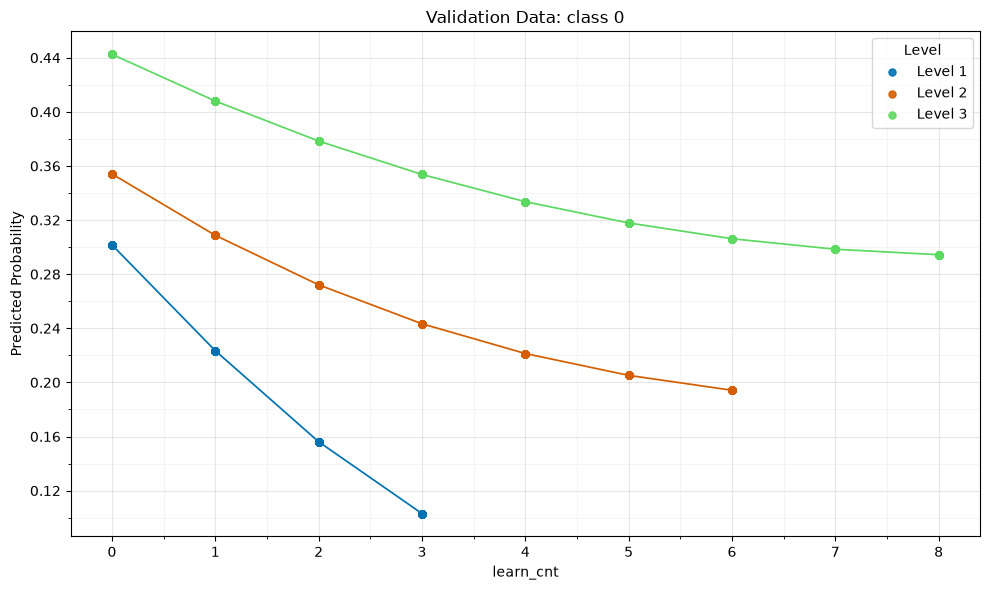

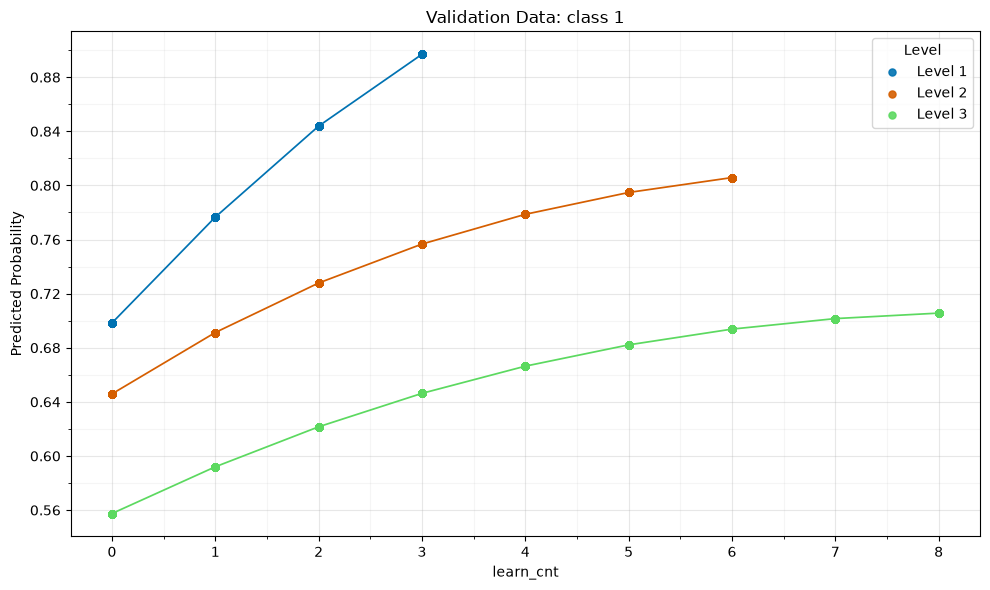

In [13]:
validation_result = training_results[CAPPED_DATASET_NAME]

validation_data = validation_result["X_test"].copy()
validation_data["a_t"] = validation_result["y_test"].to_numpy()

# Predicted probability of class 1 for every validation observation.
validation_data["model_probability"] = (
    validation_result["model"]
    .predict_proba(validation_data[FEATURE_COLUMNS])[:, 1]
)

# One row per level_t / learn_cnt combination in the validation set.
validation_combination_table = (
    validation_data
    .groupby(["level_t", "learn_cnt"], as_index=False)
    .agg(
        number_of_appearances=("a_t", "size"),
        empirical_success_rate=("a_t", "mean"),
        model_success_rate=("model_probability", "mean"),
    )
    .sort_values(["level_t", "learn_cnt"])
    .reset_index(drop=True)
)

display(validation_combination_table)

# ---------------------------------------------------------------------------
# Validation probability plots
# ---------------------------------------------------------------------------

levels = sorted(validation_data["level_t"].dropna().unique())
colours = {1: "#0072B2", 2: "#D55E00", 3: "#5CD960"}
class_columns = [
    ("probability_class_0", "Validation Data: class 0"),
    ("probability_class_1", "Validation Data: class 1"),
]

validation_probabilities = validation_result["model"].predict_proba(validation_data[FEATURE_COLUMNS])
validation_data["probability_class_0"] = validation_probabilities[:, 0]
validation_data["probability_class_1"] = validation_probabilities[:, 1]

def plot_validation_class(probability_column: str, title: str) -> None:
    fig, axis = plt.subplots(figsize=(10, 6))

    for level in levels:
        level_frame = validation_data.loc[
            validation_data["level_t"] == level,
            ["learn_cnt", probability_column]
        ]
        if level_frame.empty:
            continue

        level_frame = level_frame.sort_values("learn_cnt")
        plot_colour = colours.get(level)
        scatter_kwargs = {"s": 26, "alpha": 0.9, "label": f"Level {level}", "zorder": 3}
        line_kwargs = {"linestyle": "-", "linewidth": 1.25, "zorder": 2}
    
        if plot_colour is not None:
            scatter_kwargs["color"] = plot_colour
            line_kwargs["color"] = plot_colour

        axis.scatter(level_frame["learn_cnt"], level_frame[probability_column], **scatter_kwargs)
        axis.plot(level_frame["learn_cnt"], level_frame[probability_column], **line_kwargs)

    axis.set_xlabel("learn_cnt")
    axis.set_ylabel("Predicted Probability")
    axis.set_title(title)
    axis.xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
    axis.xaxis.set_minor_locator(AutoMinorLocator(2))
    axis.yaxis.set_major_locator(MaxNLocator(nbins=10))
    axis.yaxis.set_minor_locator(AutoMinorLocator(2))
    axis.grid(True, which="major", alpha=0.3)
    axis.grid(True, which="minor", alpha=0.12)
    axis.legend(title="Level")
    plt.tight_layout()
    plt.show()

for probability_column, title in class_columns:
    plot_validation_class(probability_column, title)


## 7. Manual Prediction

Use this section to test a single row manually.

In [14]:
example_dataset = CAPPED_DATASET_NAME
model = training_results[example_dataset]["model"]

custom_input = pd.DataFrame([{
    "level_t": 2,
    "learn_cnt": 7,
    # "a_t_minus_5": 0,
    # "a_t_minus_4": 0,
    # "a_t_minus_3": 0,
    # "a_t_minus_2": 0,
    # "a_t_minus_1": 0,
}])

print(f"Prediction for dataset: {example_dataset}")
display(custom_input)
print(f"Predicted class: {model.predict(custom_input)[0]}")
print(f"Predicted probability of class 1: {model.predict_proba(custom_input)[0, 1]:.4f}")


Prediction for dataset: obs100000MP_capped2000


,level_t,learn_cnt
0,2,7


Predicted class: 1
Predicted probability of class 1: 0.8123


## 8. How to Extend the Notebook

To add the lag columns later, change `USE_LAG_FEATURES` to `True`. That will include `a_t_minus_5` to `a_t_minus_1` without changing the rest of the notebook.